In [1]:
# CELL 1 — Dataset paths and patient counts

from pathlib import Path
import pandas as pd
import numpy as np

# Find project root regardless of whether Jupyter starts
# from the project root or the notebooks directory
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate project root. "
        "Make sure the notebook is inside the project directory."
    )

# Raw dataset location
DATA_DIR = PROJECT_ROOT / "data" / "raw"

SET_A = DATA_DIR / "training_setA"
SET_B = DATA_DIR / "training_setB"

print("Project root:", PROJECT_ROOT)
print("Set A exists:", SET_A.exists())
print("Set B exists:", SET_B.exists())

files_a = sorted(SET_A.glob("*.psv"))
files_b = sorted(SET_B.glob("*.psv"))

print("Patients in Set A:", len(files_a))
print("Patients in Set B:", len(files_b))
print("Total patient files:", len(files_a) + len(files_b))

Project root: d:\SepsiChronos HDA
Set A exists: True
Set B exists: True
Patients in Set A: 10338
Patients in Set B: 20000
Total patient files: 30338


In [2]:
# CELL 2 — Inspect one patient file

sample_file = files_a[0]

sample_df = pd.read_csv(sample_file, sep="|")

print("Patient file:", sample_file.name)
print("Dataset shape for this patient:", sample_df.shape)

print("\nColumn names:")
print(sample_df.columns.tolist())

print("\nFirst 5 rows:")
display(sample_df.head())

print("\nData types:")
print(sample_df.dtypes)

Patient file: p009999.psv
Dataset shape for this patient: (14, 41)

Column names:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel']

First 5 rows:


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
0,84,98.5,38.44,150.5,91.83,NaN,17,NaN,NaN,NaN,...,NaN,NaN,NaN,79.42,0,1,0,-0.02,2,0
1,84,97.0,NaN,161.0,94.33,NaN,18,NaN,NaN,NaN,...,NaN,NaN,NaN,79.42,0,1,0,-0.02,3,0
2,80,98.0,NaN,149.0,84.33,NaN,20,NaN,NaN,NaN,...,NaN,NaN,NaN,79.42,0,1,0,-0.02,4,0
3,78,97.5,NaN,149.0,90.67,NaN,19,NaN,NaN,NaN,...,NaN,NaN,NaN,79.42,0,1,0,-0.02,5,0
4,76,99.0,38.56,150.0,90.67,NaN,16,NaN,NaN,NaN,...,NaN,NaN,NaN,79.42,0,1,0,-0.02,6,0



Data types:
HR                    int64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                  int64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibrinogen          float64
Platelets           float64
Age                 float64
Gender 

In [3]:
# CELL 3 — Check target, ICU time and patient structure

print("Target column present:", "SepsisLabel" in sample_df.columns)
print("ICU time column present:", "ICULOS" in sample_df.columns)

print("\nPatient ID derived from filename:")
print(sample_file.stem)

print("\nTarget values for this patient:")
print(sample_df["SepsisLabel"].value_counts(dropna=False))

print("\nUnique target values:")
print(sample_df["SepsisLabel"].unique())

print("\nFirst 10 ICU hours:")
print(sample_df["ICULOS"].head(10).tolist())

print("\nLast 10 ICU hours:")
print(sample_df["ICULOS"].tail(10).tolist())

print("\nICU hour range:")
print("Minimum ICU hour:", sample_df["ICULOS"].min())
print("Maximum ICU hour:", sample_df["ICULOS"].max())

print("\nAre ICU hours ordered?")
print(sample_df["ICULOS"].is_monotonic_increasing)

Target column present: True
ICU time column present: True

Patient ID derived from filename:
p009999

Target values for this patient:
SepsisLabel
0    14
Name: count, dtype: int64

Unique target values:
[0]

First 10 ICU hours:
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Last 10 ICU hours:
[6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

ICU hour range:
Minimum ICU hour: 2
Maximum ICU hour: 15

Are ICU hours ordered?
True


In [4]:
# CELL 4 — Missing-value analysis for one patient

missing_sample = (
    sample_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing_Count")
)

missing_sample["Missing_%"] = (
    missing_sample["Missing_Count"] / len(sample_df) * 100
)

print("Top 20 features with the highest missing values:\n")
display(missing_sample.head(20))

print("\nFeatures with no missing values:\n")
display(missing_sample[missing_sample["Missing_Count"] == 0])

Top 20 features with the highest missing values:



,Missing_Count,Missing_%
EtCO2,14,100.000000
DBP,14,100.000000
BaseExcess,14,100.000000
AST,14,100.000000
Alkalinephos,14,100.000000
SaO2,14,100.000000
PaCO2,14,100.000000
pH,14,100.000000
FiO2,14,100.000000
TroponinI,14,100.000000



Features with no missing values:



,Missing_Count,Missing_%
HR,0,0.0
O2Sat,0,0.0
SBP,0,0.0
MAP,0,0.0
Resp,0,0.0
Age,0,0.0
Gender,0,0.0
Unit1,0,0.0
Unit2,0,0.0
HospAdmTime,0,0.0


In [5]:
# CELL 5 — Full dataset patient and target summary

all_files = files_a + files_b

total_rows = 0
septic_patients = 0
non_septic_patients = 0

sepsis_negative_rows = 0
sepsis_positive_rows = 0

patient_lengths = []

for i, file_path in enumerate(all_files, start=1):

    # Read only the columns needed for this summary
    df = pd.read_csv(
        file_path,
        sep="|",
        usecols=["ICULOS", "SepsisLabel"]
    )

    # Number of hourly records for this patient
    n_rows = len(df)
    total_rows += n_rows
    patient_lengths.append(n_rows)

    # Hour-level target counts
    counts = df["SepsisLabel"].value_counts()

    sepsis_negative_rows += counts.get(0, 0)
    sepsis_positive_rows += counts.get(1, 0)

    # Patient-level classification
    if (df["SepsisLabel"] == 1).any():
        septic_patients += 1
    else:
        non_septic_patients += 1

    # Progress message
    if i % 5000 == 0:
        print(f"Processed {i:,} / {len(all_files):,} patients")

print("\n========== FULL DATASET SUMMARY ==========")

print(f"Total patients: {len(all_files):,}")
print(f"Total hourly observations: {total_rows:,}")

print("\n----- Patient-level distribution -----")
print(f"Patients who develop sepsis: {septic_patients:,}")
print(f"Patients without sepsis: {non_septic_patients:,}")

print(
    f"Septic patient percentage: "
    f"{septic_patients / len(all_files) * 100:.2f}%"
)

print(
    f"Non-septic patient percentage: "
    f"{non_septic_patients / len(all_files) * 100:.2f}%"
)

print("\n----- Hour-level SepsisLabel distribution -----")
print(f"SepsisLabel = 0: {sepsis_negative_rows:,}")
print(f"SepsisLabel = 1: {sepsis_positive_rows:,}")

print(
    f"Positive hourly percentage: "
    f"{sepsis_positive_rows / total_rows * 100:.2f}%"
)

print(
    f"Negative hourly percentage: "
    f"{sepsis_negative_rows / total_rows * 100:.2f}%"
)

print("\n----- ICU observation length per patient -----")
print(f"Minimum hours: {np.min(patient_lengths)}")
print(f"Median hours: {np.median(patient_lengths):.1f}")
print(f"Mean hours: {np.mean(patient_lengths):.2f}")
print(f"Maximum hours: {np.max(patient_lengths)}")

Processed 5,000 / 30,338 patients
Processed 10,000 / 30,338 patients
Processed 15,000 / 30,338 patients
Processed 20,000 / 30,338 patients
Processed 25,000 / 30,338 patients
Processed 30,000 / 30,338 patients

========== FULL DATASET SUMMARY ==========
Total patients: 30,338
Total hourly observations: 1,163,798

----- Patient-level distribution -----
Patients who develop sepsis: 2,067
Patients without sepsis: 28,271
Septic patient percentage: 6.81%
Non-septic patient percentage: 93.19%

----- Hour-level SepsisLabel distribution -----
SepsisLabel = 0: 1,144,163
SepsisLabel = 1: 19,635
Positive hourly percentage: 1.69%
Negative hourly percentage: 98.31%

----- ICU observation length per patient -----
Minimum hours: 8
Median hours: 38.0
Mean hours: 38.36
Maximum hours: 336


In [6]:
# CELL 6 — Full dataset missing-value analysis

missing_counts = None
total_counts = None

for i, file_path in enumerate(all_files, start=1):

    df = pd.read_csv(file_path, sep="|")

    current_missing = df.isna().sum()
    current_total = pd.Series(len(df), index=df.columns)

    if missing_counts is None:
        missing_counts = current_missing.copy()
        total_counts = current_total.copy()
    else:
        missing_counts = missing_counts.add(
            current_missing,
            fill_value=0
        )
        total_counts = total_counts.add(
            current_total,
            fill_value=0
        )

    if i % 5000 == 0:
        print(
            f"Processed {i:,} / {len(all_files):,} patients"
        )

missing_summary = pd.DataFrame({
    "Missing_Count": missing_counts.astype(int),
    "Total_Count": total_counts.astype(int)
})

missing_summary["Missing_%"] = (
    missing_summary["Missing_Count"]
    / missing_summary["Total_Count"]
    * 100
)

missing_summary = missing_summary.sort_values(
    "Missing_%",
    ascending=False
)

print("\n========== FULL DATASET MISSINGNESS ==========\n")

display(missing_summary)

Processed 5,000 / 30,338 patients
Processed 10,000 / 30,338 patients
Processed 15,000 / 30,338 patients
Processed 20,000 / 30,338 patients
Processed 25,000 / 30,338 patients
Processed 30,000 / 30,338 patients

========== FULL DATASET MISSINGNESS ==========



,Missing_Count,Total_Count,Missing_%
Bilirubin_direct,1161380,1163798,99.792232
Fibrinogen,1156334,1163798,99.358652
TroponinI,1149493,1163798,98.770835
Bilirubin_total,1145259,1163798,98.407026
Alkalinephos,1144303,1163798,98.324881
AST,1144217,1163798,98.317492
PTT,1136673,1163798,97.669269
Lactate,1135891,1163798,97.602075
SaO2,1130088,1163798,97.103449
HCO3,1129907,1163798,97.087897


In [7]:
# CELL 7 — Combine all patient files into one dataset

PROCESSED_DIR = DATA_DIR.parent / "processed"   # data/processed
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COMBINED_FILE = PROCESSED_DIR / "sepsis_combined_raw.csv"

# Remove old combined file if this cell is re-run
if COMBINED_FILE.exists():
    COMBINED_FILE.unlink()

batch_size = 1000
batch_frames = []
first_write = True

def process_file(file_path, hospital_set):
    df = pd.read_csv(file_path, sep="|")

    # Add patient identifier from filename
    df["Patient_ID"] = file_path.stem

    # Identify source hospital dataset
    df["Hospital_Set"] = hospital_set

    return df


all_tagged_files = (
    [(f, "A") for f in files_a] +
    [(f, "B") for f in files_b]
)

for i, (file_path, hospital_set) in enumerate(all_tagged_files, start=1):

    patient_df = process_file(file_path, hospital_set)
    batch_frames.append(patient_df)

    # Save every 1,000 patients or at the final patient
    if len(batch_frames) == batch_size or i == len(all_tagged_files):

        batch_df = pd.concat(batch_frames, ignore_index=True)

        batch_df.to_csv(
            COMBINED_FILE,
            mode="w" if first_write else "a",
            header=first_write,
            index=False
        )

        first_write = False
        batch_frames = []

        print(
            f"Combined {i:,} / "
            f"{len(all_tagged_files):,} patients"
        )


print("\n========== COMBINATION COMPLETE ==========")
print("Saved to:")
print(COMBINED_FILE)

Combined 1,000 / 30,338 patients
Combined 2,000 / 30,338 patients
Combined 3,000 / 30,338 patients
Combined 4,000 / 30,338 patients
Combined 5,000 / 30,338 patients
Combined 6,000 / 30,338 patients
Combined 7,000 / 30,338 patients
Combined 8,000 / 30,338 patients
Combined 9,000 / 30,338 patients
Combined 10,000 / 30,338 patients
Combined 11,000 / 30,338 patients
Combined 12,000 / 30,338 patients
Combined 13,000 / 30,338 patients
Combined 14,000 / 30,338 patients
Combined 15,000 / 30,338 patients
Combined 16,000 / 30,338 patients
Combined 17,000 / 30,338 patients
Combined 18,000 / 30,338 patients
Combined 19,000 / 30,338 patients
Combined 20,000 / 30,338 patients
Combined 21,000 / 30,338 patients
Combined 22,000 / 30,338 patients
Combined 23,000 / 30,338 patients
Combined 24,000 / 30,338 patients
Combined 25,000 / 30,338 patients
Combined 26,000 / 30,338 patients
Combined 27,000 / 30,338 patients
Combined 28,000 / 30,338 patients
Combined 29,000 / 30,338 patients
Combined 30,000 / 30,33

In [8]:
# CELL 8 — Verify combined dataset

combined_df = pd.read_csv(COMBINED_FILE)

print("Combined dataset shape:", combined_df.shape)

print("\nNumber of unique patients:")
print(combined_df["Patient_ID"].nunique())

print("\nHospital set distribution:")
print(combined_df["Hospital_Set"].value_counts())

print("\nTarget distribution:")
print(combined_df["SepsisLabel"].value_counts())

print("\nTarget distribution (%):")
print(
    combined_df["SepsisLabel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFirst 5 rows:")
display(combined_df.head())

print("\nLast 5 rows:")
display(combined_df.tail())

Combined dataset shape: (1163798, 43)

Number of unique patients:
30338

Hospital set distribution:
Hospital_Set
B    761995
A    401803
Name: count, dtype: int64

Target distribution:
SepsisLabel
0    1144163
1      19635
Name: count, dtype: int64

Target distribution (%):
SepsisLabel
0    98.31
1     1.69
Name: proportion, dtype: float64

First 5 rows:


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID,Hospital_Set
0,84.0,98.5,38.44,150.5,91.83,NaN,17.0,NaN,NaN,NaN,...,NaN,79.42,0,1.0,0.0,-0.02,2,0,p009999,A
1,84.0,97.0,NaN,161.0,94.33,NaN,18.0,NaN,NaN,NaN,...,NaN,79.42,0,1.0,0.0,-0.02,3,0,p009999,A
2,80.0,98.0,NaN,149.0,84.33,NaN,20.0,NaN,NaN,NaN,...,NaN,79.42,0,1.0,0.0,-0.02,4,0,p009999,A
3,78.0,97.5,NaN,149.0,90.67,NaN,19.0,NaN,NaN,NaN,...,NaN,79.42,0,1.0,0.0,-0.02,5,0,p009999,A
4,76.0,99.0,38.56,150.0,90.67,NaN,16.0,NaN,NaN,NaN,...,NaN,79.42,0,1.0,0.0,-0.02,6,0,p009999,A



Last 5 rows:


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID,Hospital_Set
1163793,80.0,96.0,NaN,115.0,87.0,65.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,31,0,p120000,B
1163794,74.0,97.0,NaN,114.0,83.0,67.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,32,0,p120000,B
1163795,78.0,98.0,NaN,110.0,83.0,69.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,33,0,p120000,B
1163796,82.0,99.0,36.6,124.0,91.0,71.0,16.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,34,0,p120000,B
1163797,80.0,97.0,NaN,121.0,97.0,73.0,15.0,NaN,NaN,NaN,...,NaN,62.0,0,NaN,NaN,0.0,35,0,p120000,B


Unique Patient_Key count:
30338

Hour-level class counts:
SepsisLabel
0    1144163
1      19635
Name: count, dtype: int64

Hour-level class percentages:
SepsisLabel
0    98.31
1     1.69
Name: proportion, dtype: float64


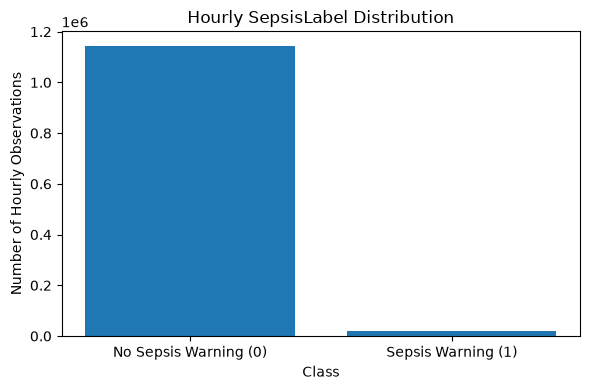

In [9]:
# CELL 9 — Create unique patient key and visualize class distribution

import matplotlib.pyplot as plt

# Guaranteed unique patient identifier
combined_df["Patient_Key"] = (
    combined_df["Hospital_Set"].astype(str)
    + "_"
    + combined_df["Patient_ID"].astype(str)
)

print("Unique Patient_Key count:")
print(combined_df["Patient_Key"].nunique())


# ----- Hour-level class distribution -----

hour_class_counts = combined_df["SepsisLabel"].value_counts().sort_index()

hour_class_percent = (
    combined_df["SepsisLabel"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nHour-level class counts:")
print(hour_class_counts)

print("\nHour-level class percentages:")
print(hour_class_percent.round(2))


plt.figure(figsize=(6, 4))

plt.bar(
    ["No Sepsis Warning (0)", "Sepsis Warning (1)"],
    hour_class_counts.values
)

plt.title("Hourly SepsisLabel Distribution")
plt.ylabel("Number of Hourly Observations")
plt.xlabel("Class")

plt.tight_layout()
plt.show()

Patient-level class counts:
SepsisLabel
0    28271
1     2067
Name: count, dtype: int64

Patient-level class percentages:
SepsisLabel
0    93.19
1     6.81
Name: proportion, dtype: float64


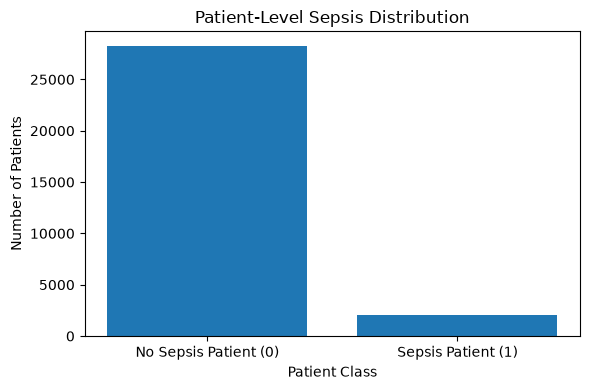

In [10]:
# CELL 10 — Patient-level Sepsis distribution

patient_level = (
    combined_df
    .groupby("Patient_Key")["SepsisLabel"]
    .max()
)

patient_counts = patient_level.value_counts().sort_index()

patient_percent = (
    patient_level
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("Patient-level class counts:")
print(patient_counts)

print("\nPatient-level class percentages:")
print(patient_percent.round(2))


plt.figure(figsize=(6, 4))

plt.bar(
    ["No Sepsis Patient (0)", "Sepsis Patient (1)"],
    patient_counts.values
)

plt.title("Patient-Level Sepsis Distribution")
plt.ylabel("Number of Patients")
plt.xlabel("Patient Class")

plt.tight_layout()
plt.show()

ICU observation length summary:
count    30338.000000
mean        38.780407
std         23.136767
min          8.000000
25%         24.000000
50%         39.000000
75%         47.000000
max        336.000000
Name: ICULOS, dtype: float64


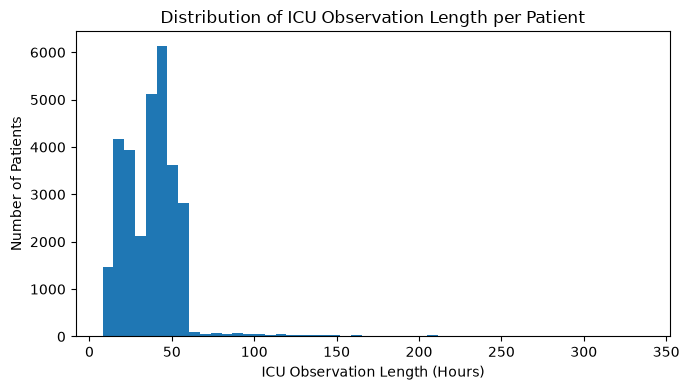

In [11]:
# CELL 11 — ICU observation length distribution

patient_hours = (
    combined_df
    .groupby("Patient_Key")["ICULOS"]
    .max()
)

print("ICU observation length summary:")
print(patient_hours.describe())

plt.figure(figsize=(7, 4))

plt.hist(
    patient_hours,
    bins=50
)

plt.title("Distribution of ICU Observation Length per Patient")
plt.xlabel("ICU Observation Length (Hours)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

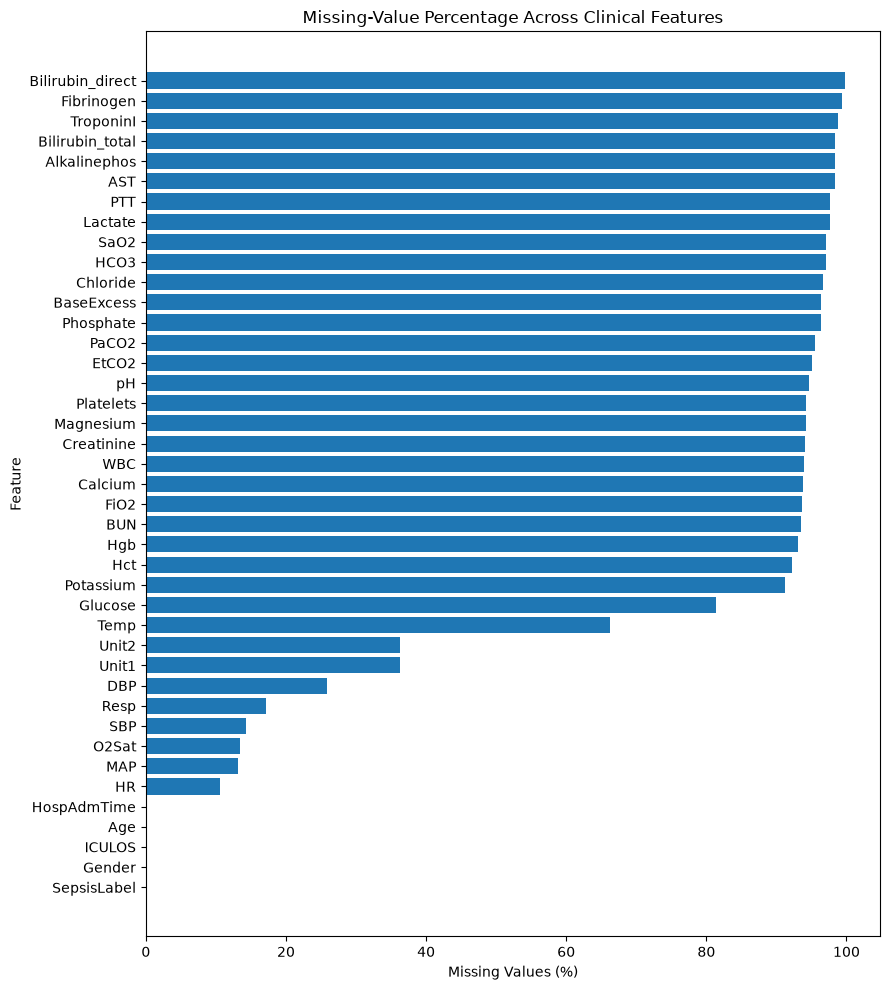

In [12]:
# CELL 12 — Visualize full-dataset missingness

missing_plot = (
    missing_summary
    .reset_index()
    .rename(columns={"index": "Feature"})
    .sort_values("Missing_%", ascending=True)
)

plt.figure(figsize=(9, 10))

plt.barh(
    missing_plot["Feature"],
    missing_plot["Missing_%"]
)

plt.title("Missing-Value Percentage Across Clinical Features")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Summary of key vital signs by SepsisLabel:


HR                O2Sat                Temp               \
              mean median    std   mean median   std   mean median   std   
SepsisLabel                                                                
0            84.28   83.0  17.41  97.17   98.0  2.94  36.95  36.94  0.75   
1            90.74   90.0  19.27  96.97   98.0  3.36  37.24  37.28  1.06   

                SBP                  MAP                 Resp               
               mean median    std   mean median    std   mean median   std  
SepsisLabel                                                                 
0            124.81  122.0  23.68  83.75   82.0  16.58  18.67   18.0  4.96  
1            121.98  119.0  25.67  80.96   78.0  17.03  20.30   20.0  6.16

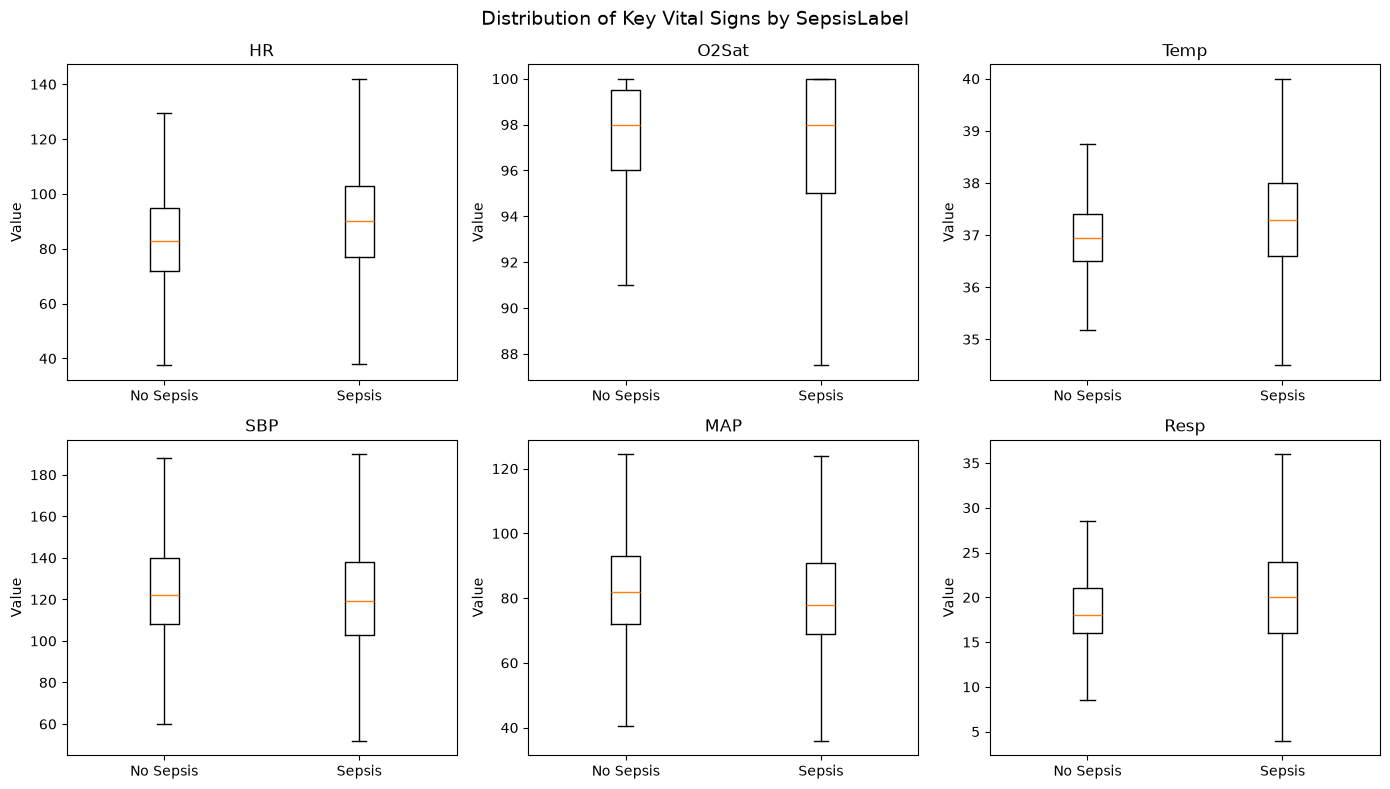

In [14]:
# CELL 13 — Compare important vital signs by SepsisLabel

key_vitals = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]

vital_summary = (
    combined_df
    .groupby("SepsisLabel")[key_vitals]
    .agg(["mean", "median", "std"])
    .round(2)
)

print("Summary of key vital signs by SepsisLabel:")
display(vital_summary)

# Boxplots for selected vital signs

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, feature in zip(axes.flatten(), key_vitals):
    
    data_0 = combined_df.loc[
        combined_df["SepsisLabel"] == 0, feature
    ].dropna()

    data_1 = combined_df.loc[
        combined_df["SepsisLabel"] == 1, feature
    ].dropna()

    ax.boxplot(
    [data_0, data_1],
    tick_labels=["No Sepsis", "Sepsis"],
    showfliers=False
)

    ax.set_title(feature)
    ax.set_ylabel("Value")

plt.suptitle(
    "Distribution of Key Vital Signs by SepsisLabel",
    fontsize=14
)

plt.tight_layout()
plt.show()

Correlation matrix:


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,ICULOS,SepsisLabel
HR,1.00,-0.07,0.26,-0.03,0.06,0.12,0.22,-0.15,0.05,0.05
O2Sat,-0.07,1.00,-0.03,0.02,0.02,0.00,-0.14,-0.05,-0.05,-0.01
Temp,0.26,-0.03,1.00,0.00,-0.07,-0.11,0.12,-0.06,0.08,0.05
SBP,-0.03,0.02,0.00,1.00,0.78,0.54,0.05,0.03,0.05,-0.02
MAP,0.06,0.02,-0.07,0.78,1.00,0.86,0.05,-0.14,0.03,-0.02
DBP,0.12,0.00,-0.11,0.54,0.86,1.00,0.06,-0.25,0.01,-0.02
Resp,0.22,-0.14,0.12,0.05,0.05,0.06,1.00,0.03,0.09,0.04
Age,-0.15,-0.05,-0.06,0.03,-0.14,-0.25,0.03,1.00,0.01,0.00
ICULOS,0.05,-0.05,0.08,0.05,0.03,0.01,0.09,0.01,1.00,0.13
SepsisLabel,0.05,-0.01,0.05,-0.02,-0.02,-0.02,0.04,0.00,0.13,1.00


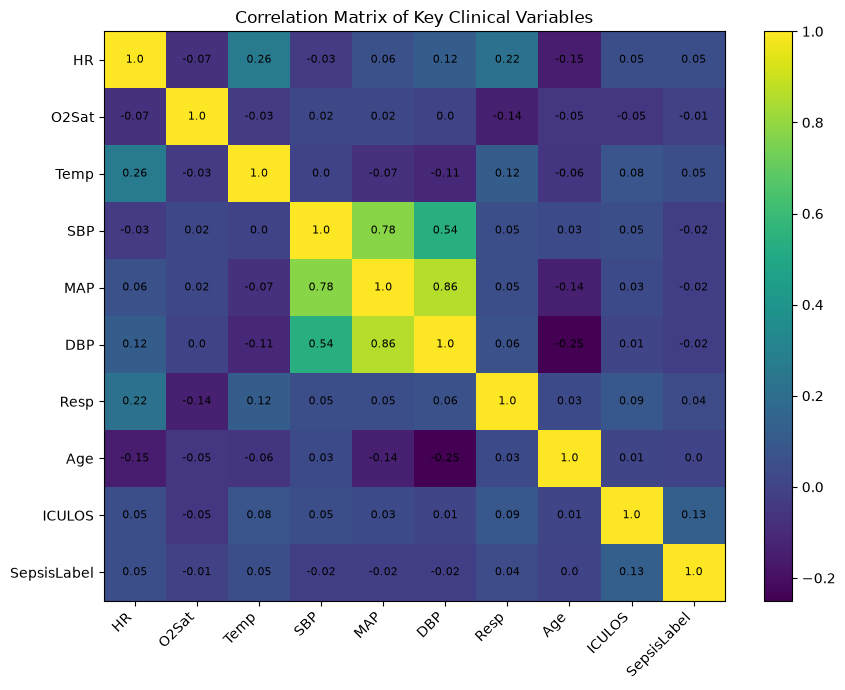

In [15]:
# CELL 14 — Correlation analysis of key variables

correlation_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp",
    "Age",
    "ICULOS",
    "SepsisLabel"
]

corr_matrix = (
    combined_df[correlation_features]
    .corr()
    .round(2)
)

print("Correlation matrix:")
display(corr_matrix)


# Correlation heatmap using Matplotlib

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(corr_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_features)))
ax.set_yticks(range(len(correlation_features)))

ax.set_xticklabels(
    correlation_features,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(correlation_features)

# Write correlation values inside cells
for i in range(len(correlation_features)):
    for j in range(len(correlation_features)):
        ax.text(
            j,
            i,
            corr_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, ax=ax)

plt.title("Correlation Matrix of Key Clinical Variables")
plt.tight_layout()
plt.show()

In [16]:
# CELL 15 — Data-quality checks

# 1. Exact duplicate rows
exact_duplicates = combined_df.duplicated().sum()

print("Exact duplicate rows:")
print(exact_duplicates)


# 2. Duplicate Patient_Key + ICULOS combinations
patient_hour_duplicates = combined_df.duplicated(
    subset=["Patient_Key", "ICULOS"]
).sum()

print("\nDuplicate Patient_Key + ICULOS records:")
print(patient_hour_duplicates)


# 3. Infinite values in numerical columns
numeric_cols = combined_df.select_dtypes(
    include=[np.number]
).columns

infinite_counts = pd.Series({
    col: np.isinf(combined_df[col]).sum()
    for col in numeric_cols
})

infinite_counts = infinite_counts[
    infinite_counts > 0
].sort_values(ascending=False)

print("\nColumns containing infinite values:")

if len(infinite_counts) == 0:
    print("No infinite values detected.")
else:
    display(infinite_counts)


# 4. Check ICU-hour ordering within each patient
ordering_check = (
    combined_df
    .groupby("Patient_Key")["ICULOS"]
    .apply(lambda x: x.is_monotonic_increasing)
)

unordered_patients = (~ordering_check).sum()

print("\nPatients with unordered ICU hours:")
print(unordered_patients)


# 5. Missing target values
print("\nMissing SepsisLabel values:")
print(combined_df["SepsisLabel"].isna().sum())


# 6. Unexpected target values
print("\nUnique SepsisLabel values:")
print(sorted(combined_df["SepsisLabel"].dropna().unique()))

Exact duplicate rows:
0

Duplicate Patient_Key + ICULOS records:
0

Columns containing infinite values:
No infinite values detected.

Patients with unordered ICU hours:
0

Missing SepsisLabel values:
0

Unique SepsisLabel values:
[np.int64(0), np.int64(1)]


In [17]:
# CELL 16 — Inspect ranges and potential outliers in key clinical variables

key_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp",
    "Age"
]

range_summary = pd.DataFrame({
    "Min": combined_df[key_features].min(),
    "Q1": combined_df[key_features].quantile(0.25),
    "Median": combined_df[key_features].median(),
    "Q3": combined_df[key_features].quantile(0.75),
    "Max": combined_df[key_features].max()
}).round(2)

print("Range summary of key clinical variables:")
display(range_summary)


# IQR-based potential outlier counts
outlier_results = []

for feature in key_features:
    series = combined_df[feature].dropna()

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    outlier_results.append({
        "Feature": feature,
        "Lower_IQR_Bound": round(lower_bound, 2),
        "Upper_IQR_Bound": round(upper_bound, 2),
        "Potential_Outliers": int(outlier_count),
        "Outlier_%": round(
            outlier_count / len(series) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_results)

print("\nIQR-based potential outlier summary:")
display(outlier_summary)

Range summary of key clinical variables:


,Min,Q1,Median,Q3,Max
HR,20.0,72.0,83.00,95.00,211.0
O2Sat,20.0,96.0,98.00,99.50,100.0
Temp,23.0,36.5,36.95,37.44,50.0
SBP,20.0,107.0,122.00,140.00,300.0
MAP,20.0,72.0,82.00,93.00,300.0
DBP,20.0,55.0,63.00,73.00,300.0
Resp,1.0,16.0,18.00,21.00,100.0
Age,14.0,51.0,63.00,73.96,100.0



IQR-based potential outlier summary:


,Feature,Lower_IQR_Bound,Upper_IQR_Bound,Potential_Outliers,Outlier_%
0,HR,37.50,129.50,12373,1.19
1,O2Sat,90.75,104.75,19057,1.89
2,Temp,35.09,38.85,6895,1.75
3,SBP,57.50,189.50,9378,0.94
4,MAP,40.50,124.50,17597,1.74
5,DBP,28.00,100.00,13549,1.57
6,Resp,8.50,28.50,42759,4.44
7,Age,16.56,108.40,324,0.03


In [18]:
# CELL 17 — Detailed extreme-value inspection

key_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "DBP",
    "Resp",
    "Age"
]

quantile_summary = pd.DataFrame({
    "Min": combined_df[key_features].min(),
    "0.1%": combined_df[key_features].quantile(0.001),
    "1%": combined_df[key_features].quantile(0.01),
    "5%": combined_df[key_features].quantile(0.05),
    "Median": combined_df[key_features].median(),
    "95%": combined_df[key_features].quantile(0.95),
    "99%": combined_df[key_features].quantile(0.99),
    "99.9%": combined_df[key_features].quantile(0.999),
    "Max": combined_df[key_features].max()
}).round(2)

print("Detailed distribution of key clinical variables:")
display(quantile_summary)

Detailed distribution of key clinical variables:


,Min,0.1%,1%,5%,Median,95%,99%,99.9%,Max
HR,20.0,40.0,50.00,58.0,83.00,115.0,130.0,150.00,211.0
O2Sat,20.0,73.5,89.00,92.0,98.00,100.0,100.0,100.00,100.0
Temp,23.0,33.0,35.11,35.8,36.95,38.2,38.8,39.72,50.0
SBP,20.0,64.0,80.00,91.0,122.00,167.0,188.0,216.00,300.0
MAP,20.0,41.0,53.00,61.0,82.00,113.0,130.0,159.00,300.0
DBP,20.0,29.0,38.00,45.0,63.00,90.0,104.0,131.00,300.0
Resp,1.0,2.0,9.00,12.0,18.00,28.0,34.0,43.00,100.0
Age,14.0,18.0,21.00,30.0,63.00,85.0,100.0,100.00,100.0


In [19]:
# CELL 18 — Patient-level stratified train/test split

from sklearn.model_selection import train_test_split

# Create one outcome per patient:
# 0 = patient never enters sepsis-warning period
# 1 = patient has at least one positive SepsisLabel
patient_outcomes = (
    combined_df
    .groupby("Patient_Key")["SepsisLabel"]
    .max()
    .reset_index()
)

train_patients, test_patients = train_test_split(
    patient_outcomes,
    test_size=0.20,
    random_state=42,
    stratify=patient_outcomes["SepsisLabel"]
)

train_patient_keys = set(train_patients["Patient_Key"])
test_patient_keys = set(test_patients["Patient_Key"])

print("========== PATIENT-LEVEL SPLIT ==========")

print("Training patients:", len(train_patient_keys))
print("Testing patients:", len(test_patient_keys))

print("\nPatient overlap between train and test:")
print(len(train_patient_keys.intersection(test_patient_keys)))

print("\nTraining patient outcome distribution (%):")
print(
    train_patients["SepsisLabel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting patient outcome distribution (%):")
print(
    test_patients["SepsisLabel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

========== PATIENT-LEVEL SPLIT ==========
Training patients: 24270
Testing patients: 6068

Patient overlap between train and test:
0

Training patient outcome distribution (%):
SepsisLabel
0    93.19
1     6.81
Name: proportion, dtype: float64

Testing patient outcome distribution (%):
SepsisLabel
0    93.19
1     6.81
Name: proportion, dtype: float64


In [20]:
# CELL 19 — Create train and test hourly datasets

train_df = combined_df[
    combined_df["Patient_Key"].isin(train_patient_keys)
].copy()

test_df = combined_df[
    combined_df["Patient_Key"].isin(test_patient_keys)
].copy()


print("========== TRAIN / TEST DATASETS ==========")

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

print("\nTraining unique patients:")
print(train_df["Patient_Key"].nunique())

print("\nTesting unique patients:")
print(test_df["Patient_Key"].nunique())


print("\n----- Training hour-level class distribution -----")
print(train_df["SepsisLabel"].value_counts())

print("\nTraining hour-level class distribution (%):")
print(
    train_df["SepsisLabel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


print("\n----- Testing hour-level class distribution -----")
print(test_df["SepsisLabel"].value_counts())

print("\nTesting hour-level class distribution (%):")
print(
    test_df["SepsisLabel"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

========== TRAIN / TEST DATASETS ==========
Training dataset shape: (931285, 44)
Testing dataset shape: (232513, 44)

Training unique patients:
24270

Testing unique patients:
6068

----- Training hour-level class distribution -----
SepsisLabel
0    915552
1     15733
Name: count, dtype: int64

Training hour-level class distribution (%):
SepsisLabel
0    98.31
1     1.69
Name: proportion, dtype: float64

----- Testing hour-level class distribution -----
SepsisLabel
0    228611
1      3902
Name: count, dtype: int64

Testing hour-level class distribution (%):
SepsisLabel
0    98.32
1     1.68
Name: proportion, dtype: float64


In [21]:
# CELL 20 — Patient-wise forward filling

# Make separate cleaned copies
train_clean = train_df.copy()
test_clean = test_df.copy()

# Ensure proper chronological ordering
train_clean = train_clean.sort_values(
    ["Patient_Key", "ICULOS"]
).reset_index(drop=True)

test_clean = test_clean.sort_values(
    ["Patient_Key", "ICULOS"]
).reset_index(drop=True)


# Columns that must NOT be forward-filled
exclude_cols = [
    "SepsisLabel",
    "Patient_ID",
    "Patient_Key",
    "Hospital_Set",
    "ICULOS"
]

feature_cols = [
    col for col in train_clean.columns
    if col not in exclude_cols
]


# Missing values BEFORE forward fill
train_missing_before = train_clean[feature_cols].isna().sum().sum()
test_missing_before = test_clean[feature_cols].isna().sum().sum()


# Forward-fill WITHIN each patient only
train_clean[feature_cols] = (
    train_clean
    .groupby("Patient_Key")[feature_cols]
    .ffill()
)

test_clean[feature_cols] = (
    test_clean
    .groupby("Patient_Key")[feature_cols]
    .ffill()
)


# Missing values AFTER forward fill
train_missing_after = train_clean[feature_cols].isna().sum().sum()
test_missing_after = test_clean[feature_cols].isna().sum().sum()


print("========== FORWARD-FILL SUMMARY ==========")

print("\nTraining data:")
print(f"Missing values before: {train_missing_before:,}")
print(f"Missing values after : {train_missing_after:,}")

print(
    f"Reduction: "
    f"{(train_missing_before - train_missing_after) / train_missing_before * 100:.2f}%"
)

print("\nTesting data:")
print(f"Missing values before: {test_missing_before:,}")
print(f"Missing values after : {test_missing_after:,}")

print(
    f"Reduction: "
    f"{(test_missing_before - test_missing_after) / test_missing_before * 100:.2f}%"
)

========== FORWARD-FILL SUMMARY ==========

Training data:
Missing values before: 26,133,433
Missing values after : 14,352,235
Reduction: 45.08%

Testing data:
Missing values before: 6,517,360
Missing values after : 3,584,127
Reduction: 45.01%


In [22]:
# CELL 21 — Remaining missingness after patient-wise forward fill

train_remaining_missing = pd.DataFrame({
    "Missing_Count": train_clean[feature_cols].isna().sum(),
    "Missing_%": (
        train_clean[feature_cols].isna().mean() * 100
    )
}).sort_values("Missing_%", ascending=False)

test_remaining_missing = pd.DataFrame({
    "Missing_Count": test_clean[feature_cols].isna().sum(),
    "Missing_%": (
        test_clean[feature_cols].isna().mean() * 100
    )
}).sort_values("Missing_%", ascending=False)


print("========== TRAINING DATA AFTER FORWARD FILL ==========\n")
display(train_remaining_missing)

print("\n========== TESTING DATA AFTER FORWARD FILL ==========\n")
display(test_remaining_missing)


print("\nFeatures completely missing in TRAINING data:")
completely_missing_train = train_remaining_missing[
    train_remaining_missing["Missing_%"] == 100
]

if len(completely_missing_train) == 0:
    print("None")
else:
    display(completely_missing_train)

========== TRAINING DATA AFTER FORWARD FILL ==========



,Missing_Count,Missing_%
Bilirubin_direct,879999,94.492985
Fibrinogen,833904,89.543373
EtCO2,826558,88.754570
TroponinI,748917,80.417595
BaseExcess,722426,77.573031
Lactate,671808,72.137745
SaO2,666666,71.585605
HCO3,647705,69.549601
Bilirubin_total,629852,67.632572
Alkalinephos,628605,67.498671



========== TESTING DATA AFTER FORWARD FILL ==========



,Missing_Count,Missing_%
Bilirubin_direct,220317,94.754702
Fibrinogen,207150,89.091793
EtCO2,206667,88.884062
TroponinI,189311,81.419534
BaseExcess,181698,78.145308
Lactate,168532,72.482829
SaO2,166591,71.648037
HCO3,165054,70.986999
Bilirubin_total,156971,67.510634
Alkalinephos,156571,67.338600



Features completely missing in TRAINING data:
None


In [23]:
# CELL 22 — Final missing-value imputation using TRAINING data only

# Binary / categorical numeric variables
categorical_cols = ["Gender", "Unit1", "Unit2"]

# All remaining clinical variables are treated as continuous numeric features
continuous_cols = [
    col for col in feature_cols
    if col not in categorical_cols
]


# ---------------------------------------------------
# 1. Learn imputation values from TRAINING data only
# ---------------------------------------------------

# Median for continuous variables
train_medians = train_clean[continuous_cols].median()

# Mode for categorical/binary variables
train_modes = {}

for col in categorical_cols:
    mode_values = train_clean[col].mode(dropna=True)

    if len(mode_values) > 0:
        train_modes[col] = mode_values.iloc[0]


# ---------------------------------------------------
# 2. Apply TRAINING-derived values to TRAINING data
# ---------------------------------------------------

train_clean[continuous_cols] = (
    train_clean[continuous_cols]
    .fillna(train_medians)
)

for col, mode_value in train_modes.items():
    train_clean[col] = train_clean[col].fillna(mode_value)


# ---------------------------------------------------
# 3. Apply SAME values to TEST data
# ---------------------------------------------------

test_clean[continuous_cols] = (
    test_clean[continuous_cols]
    .fillna(train_medians)
)

for col, mode_value in train_modes.items():
    test_clean[col] = test_clean[col].fillna(mode_value)


# ---------------------------------------------------
# 4. Verify remaining missing values
# ---------------------------------------------------

train_missing_final = (
    train_clean[feature_cols]
    .isna()
    .sum()
    .sum()
)

test_missing_final = (
    test_clean[feature_cols]
    .isna()
    .sum()
    .sum()
)


print("========== FINAL IMPUTATION SUMMARY ==========")

print("\nTraining data:")
print("Remaining missing feature values:", train_missing_final)

print("\nTesting data:")
print("Remaining missing feature values:", test_missing_final)


print("\nCategorical imputation values learned from training data:")
print(train_modes)


print("\nExample continuous medians learned from training data:")
example_cols = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp",
    "Creatinine",
    "Lactate"
]

display(train_medians[example_cols].to_frame("Training_Median"))

========== FINAL IMPUTATION SUMMARY ==========

Training data:
Remaining missing feature values: 0

Testing data:
Remaining missing feature values: 0

Categorical imputation values learned from training data:
{'Gender': np.int64(1), 'Unit1': np.float64(0.0), 'Unit2': np.float64(1.0)}

Example continuous medians learned from training data:


,Training_Median
HR,83.00
O2Sat,98.00
Temp,36.80
SBP,122.00
MAP,82.00
Resp,18.00
Creatinine,0.93
Lactate,1.59


In [24]:
# CELL 23 — Prepare modelling features and target variables

# Columns that should NOT be given to the ML model
non_feature_cols = [
    "SepsisLabel",
    "Patient_ID",
    "Patient_Key",
    "Hospital_Set"
]

# All remaining columns become baseline model features
model_features = [
    col for col in train_clean.columns
    if col not in non_feature_cols
]


# ---------------------------------------------------
# Create X and y
# ---------------------------------------------------

X_train = train_clean[model_features].copy()
X_test = test_clean[model_features].copy()

y_train = train_clean["SepsisLabel"].copy()
y_test = test_clean["SepsisLabel"].copy()


# ---------------------------------------------------
# Convert features to float32 to reduce memory usage
# ---------------------------------------------------

X_train = X_train.astype("float32")
X_test = X_test.astype("float32")


# ---------------------------------------------------
# Verification
# ---------------------------------------------------

print("========== MODELLING DATASET ==========")

print("\nNumber of model features:")
print(len(model_features))

print("\nModel features:")
print(model_features)

print("\nX_train shape:")
print(X_train.shape)

print("\nX_test shape:")
print(X_test.shape)

print("\ny_train shape:")
print(y_train.shape)

print("\ny_test shape:")
print(y_test.shape)

print("\nMissing values in X_train:")
print(X_train.isna().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum().sum())

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

========== MODELLING DATASET ==========

Number of model features:
40

Model features:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']

X_train shape:
(931285, 40)

X_test shape:
(232513, 40)

y_train shape:
(931285,)

y_test shape:
(232513,)

Missing values in X_train:
0

Missing values in X_test:
0

Training target distribution:
SepsisLabel
0    915552
1     15733
Name: count, dtype: int64

Testing target distribution:
SepsisLabel
0    228611
1      3902
Name: count, dtype: int64


In [25]:
# CELL 24 — Standardize continuous features for Logistic Regression

from sklearn.preprocessing import StandardScaler

# Binary variables do not need continuous scaling
binary_features = [
    "Gender",
    "Unit1",
    "Unit2"
]

# All remaining model features are continuous/numerical
continuous_model_features = [
    col for col in model_features
    if col not in binary_features
]

# Make copies so original X_train / X_test remain unchanged
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Create scaler
scaler = StandardScaler()

# IMPORTANT:
# Fit ONLY on training data
X_train_scaled[continuous_model_features] = (
    scaler
    .fit_transform(X_train[continuous_model_features])
    .astype("float32")
)

# Apply same training-fitted scaler to test data
X_test_scaled[continuous_model_features] = (
    scaler
    .transform(X_test[continuous_model_features])
    .astype("float32")
)


# ---------------------------------------------------
# Verification
# ---------------------------------------------------

print("========== STANDARDIZATION SUMMARY ==========")

print("\nNumber of continuous features scaled:")
print(len(continuous_model_features))

print("\nBinary features left unchanged:")
print(binary_features)

print("\nX_train_scaled shape:")
print(X_train_scaled.shape)

print("\nX_test_scaled shape:")
print(X_test_scaled.shape)

print("\nMissing values in scaled training data:")
print(X_train_scaled.isna().sum().sum())

print("\nMissing values in scaled testing data:")
print(X_test_scaled.isna().sum().sum())


# Check a few training features after scaling
check_features = [
    "HR",
    "O2Sat",
    "Temp",
    "SBP",
    "MAP",
    "Resp",
    "Creatinine",
    "Lactate"
]

scaling_check = pd.DataFrame({
    "Mean_after_scaling":
        X_train_scaled[check_features].mean(),
    "Std_after_scaling":
        X_train_scaled[check_features].std()
}).round(3)

print("\nScaling verification using TRAINING data:")
display(scaling_check)

========== STANDARDIZATION SUMMARY ==========

Number of continuous features scaled:
37

Binary features left unchanged:
['Gender', 'Unit1', 'Unit2']

X_train_scaled shape:
(931285, 40)

X_test_scaled shape:
(232513, 40)

Missing values in scaled training data:
0

Missing values in scaled testing data:
0

Scaling verification using TRAINING data:


,Mean_after_scaling,Std_after_scaling
HR,-0.0,1.0
O2Sat,0.0,1.0
Temp,0.0,1.0
SBP,0.0,1.0
MAP,0.0,1.0
Resp,0.0,1.0
Creatinine,0.0,1.0
Lactate,0.0,1.0


In [26]:
# CELL 25 — Train baseline Logistic Regression

from sklearn.linear_model import LogisticRegression
import time

print("========== BASELINE LOGISTIC REGRESSION ==========")

# Start timer
start_time = time.time()

# Baseline Logistic Regression
# No class weighting yet
lr_baseline = LogisticRegression(
    solver="lbfgs",
    max_iter=500,
    class_weight=None
)

# Train model
lr_baseline.fit(
    X_train_scaled,
    y_train
)

training_time = time.time() - start_time

print("\nModel training completed.")

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print("\nNumber of iterations used:")
print(lr_baseline.n_iter_)

print("\nModel classes:")
print(lr_baseline.classes_)

print("\nNumber of learned coefficients:")
print(lr_baseline.coef_.shape)

========== BASELINE LOGISTIC REGRESSION ==========

Model training completed.
Training time: 2.03 seconds

Number of iterations used:
[16]

Model classes:
[0 1]

Number of learned coefficients:
(1, 40)


========== BASELINE LOGISTIC REGRESSION EVALUATION ==========

Confusion Matrix:

                 Predicted 0    Predicted 1
Actual 0            228,489           122
Actual 1              3,887            15

Performance Metrics:
Accuracy    : 0.9828
Precision   : 0.1095
Recall      : 0.0038
Specificity : 0.9995
F1-score    : 0.0074
ROC-AUC     : 0.7078
AUPRC       : 0.0599

Prediction distribution:
Predicted class 0: 232,376
Predicted class 1: 137


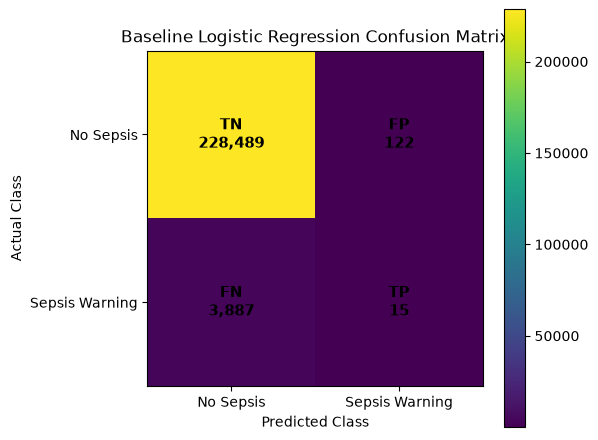

In [27]:
# CELL 26 — Evaluate baseline Logistic Regression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ---------------------------------------------------
# 1. Generate predictions
# ---------------------------------------------------

# Binary prediction using default threshold = 0.50
y_pred_baseline = lr_baseline.predict(X_test_scaled)

# Probability of SepsisLabel = 1
y_prob_baseline = lr_baseline.predict_proba(
    X_test_scaled
)[:, 1]


# ---------------------------------------------------
# 2. Confusion matrix
# ---------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_baseline
).ravel()


# ---------------------------------------------------
# 3. Evaluation metrics
# ---------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred_baseline
)

precision = precision_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_baseline,
    zero_division=0
)

specificity = tn / (tn + fp)

roc_auc = roc_auc_score(
    y_test,
    y_prob_baseline
)

auprc = average_precision_score(
    y_test,
    y_prob_baseline
)


# ---------------------------------------------------
# 4. Print results
# ---------------------------------------------------

print("========== BASELINE LOGISTIC REGRESSION EVALUATION ==========")

print("\nConfusion Matrix:")
print(
    f"""
                 Predicted 0    Predicted 1
Actual 0         {tn:10,}    {fp:10,}
Actual 1         {fn:10,}    {tp:10,}
"""
)

print("Performance Metrics:")
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1-score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"AUPRC       : {auprc:.4f}")

print("\nPrediction distribution:")
unique, counts = np.unique(
    y_pred_baseline,
    return_counts=True
)

for label, count in zip(unique, counts):
    print(
        f"Predicted class {label}: "
        f"{count:,}"
    )


# ---------------------------------------------------
# 5. Confusion matrix visualization
# ---------------------------------------------------

# Re-plot confusion matrix with TN / FP / FN / TP labels

cm = np.array([
    [tn, fp],
    [fn, tp]
])

label_matrix = np.array([
    [f"TN\n{tn:,}", f"FP\n{fp:,}"],
    [f"FN\n{fn:,}", f"TP\n{tp:,}"]
])

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["No Sepsis", "Sepsis Warning"])
ax.set_yticklabels(["No Sepsis", "Sepsis Warning"])

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_title("Baseline Logistic Regression Confusion Matrix")

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            label_matrix[i, j],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [28]:
# CELL 27 — Train class-weighted Logistic Regression

print("========== CLASS-WEIGHTED LOGISTIC REGRESSION ==========")

start_time = time.time()

# Give greater importance to the minority Sepsis class
lr_balanced = LogisticRegression(
    solver="lbfgs",
    max_iter=500,
    class_weight="balanced"
)

# Train on the SAME scaled training dataset
lr_balanced.fit(
    X_train_scaled,
    y_train
)

balanced_training_time = time.time() - start_time

print("\nModel training completed.")

print(
    f"Training time: "
    f"{balanced_training_time:.2f} seconds"
)

print("\nNumber of iterations used:")
print(lr_balanced.n_iter_)

print("\nModel classes:")
print(lr_balanced.classes_)

print("\nNumber of learned coefficients:")
print(lr_balanced.coef_.shape)

========== CLASS-WEIGHTED LOGISTIC REGRESSION ==========

Model training completed.
Training time: 3.69 seconds

Number of iterations used:
[31]

Model classes:
[0 1]

Number of learned coefficients:
(1, 40)


========== CLASS-WEIGHTED LR EVALUATION ==========

Confusion Matrix:

                 Predicted 0    Predicted 1
Actual 0            172,050        56,561
Actual 1              1,557         2,345

Performance Metrics:
Accuracy    : 0.7500
Precision   : 0.0398
Recall      : 0.6010
Specificity : 0.7526
F1-score    : 0.0747
ROC-AUC     : 0.7194
AUPRC       : 0.0606

Prediction distribution:
Predicted class 0: 173,607
Predicted class 1: 58,906


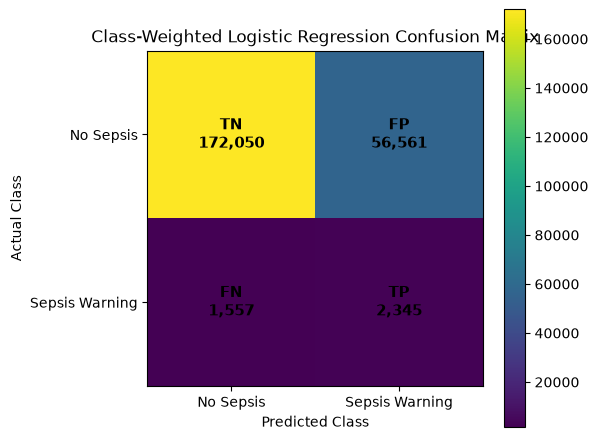

In [29]:
# CELL 28 — Evaluate class-weighted Logistic Regression

# ---------------------------------------------------
# 1. Predictions
# ---------------------------------------------------

y_pred_balanced = lr_balanced.predict(X_test_scaled)

y_prob_balanced = lr_balanced.predict_proba(
    X_test_scaled
)[:, 1]


# ---------------------------------------------------
# 2. Confusion matrix
# ---------------------------------------------------

tn_b, fp_b, fn_b, tp_b = confusion_matrix(
    y_test,
    y_pred_balanced
).ravel()


# ---------------------------------------------------
# 3. Metrics
# ---------------------------------------------------

accuracy_b = accuracy_score(
    y_test,
    y_pred_balanced
)

precision_b = precision_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

recall_b = recall_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

f1_b = f1_score(
    y_test,
    y_pred_balanced,
    zero_division=0
)

specificity_b = tn_b / (tn_b + fp_b)

roc_auc_b = roc_auc_score(
    y_test,
    y_prob_balanced
)

auprc_b = average_precision_score(
    y_test,
    y_prob_balanced
)


# ---------------------------------------------------
# 4. Print results
# ---------------------------------------------------

print("========== CLASS-WEIGHTED LR EVALUATION ==========")

print("\nConfusion Matrix:")

print(
    f"""
                 Predicted 0    Predicted 1
Actual 0         {tn_b:10,}    {fp_b:10,}
Actual 1         {fn_b:10,}    {tp_b:10,}
"""
)

print("Performance Metrics:")
print(f"Accuracy    : {accuracy_b:.4f}")
print(f"Precision   : {precision_b:.4f}")
print(f"Recall      : {recall_b:.4f}")
print(f"Specificity : {specificity_b:.4f}")
print(f"F1-score    : {f1_b:.4f}")
print(f"ROC-AUC     : {roc_auc_b:.4f}")
print(f"AUPRC       : {auprc_b:.4f}")


print("\nPrediction distribution:")

unique, counts = np.unique(
    y_pred_balanced,
    return_counts=True
)

for label, count in zip(unique, counts):
    print(
        f"Predicted class {label}: "
        f"{count:,}"
    )


# ---------------------------------------------------
# 5. Labeled confusion matrix
# ---------------------------------------------------

cm_balanced = np.array([
    [tn_b, fp_b],
    [fn_b, tp_b]
])

label_matrix_balanced = np.array([
    [f"TN\n{tn_b:,}", f"FP\n{fp_b:,}"],
    [f"FN\n{fn_b:,}", f"TP\n{tp_b:,}"]
])

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm_balanced)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "No Sepsis",
    "Sepsis Warning"
])

ax.set_yticklabels([
    "No Sepsis",
    "Sepsis Warning"
])

ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

ax.set_title(
    "Class-Weighted Logistic Regression Confusion Matrix"
)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            label_matrix_balanced[i, j],
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold"
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [30]:
# CELL 29 — Compare baseline vs class-weighted Logistic Regression

comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "AUPRC"
    ],

    "Baseline LR": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        auprc
    ],

    "Class-Weighted LR": [
        accuracy_b,
        precision_b,
        recall_b,
        specificity_b,
        f1_b,
        roc_auc_b,
        auprc_b
    ]
})

comparison_df[
    ["Baseline LR", "Class-Weighted LR"]
] = comparison_df[
    ["Baseline LR", "Class-Weighted LR"]
].round(4)


print("========== LOGISTIC REGRESSION MODEL COMPARISON ==========\n")

display(comparison_df)


# Confusion-matrix count comparison

confusion_comparison = pd.DataFrame({
    "Outcome": [
        "True Negative (TN)",
        "False Positive (FP)",
        "False Negative (FN)",
        "True Positive (TP)"
    ],

    "Baseline LR": [
        tn,
        fp,
        fn,
        tp
    ],

    "Class-Weighted LR": [
        tn_b,
        fp_b,
        fn_b,
        tp_b
    ]
})

print("\nConfusion Matrix Comparison:\n")

display(confusion_comparison)

========== LOGISTIC REGRESSION MODEL COMPARISON ==========



,Metric,Baseline LR,Class-Weighted LR
0,Accuracy,0.9828,0.7500
1,Precision,0.1095,0.0398
2,Recall,0.0038,0.6010
3,Specificity,0.9995,0.7526
4,F1-score,0.0074,0.0747
5,ROC-AUC,0.7078,0.7194
6,AUPRC,0.0599,0.0606



Confusion Matrix Comparison:



,Outcome,Baseline LR,Class-Weighted LR
0,True Negative (TN),228489,172050
1,False Positive (FP),122,56561
2,False Negative (FN),3887,1557
3,True Positive (TP),15,2345


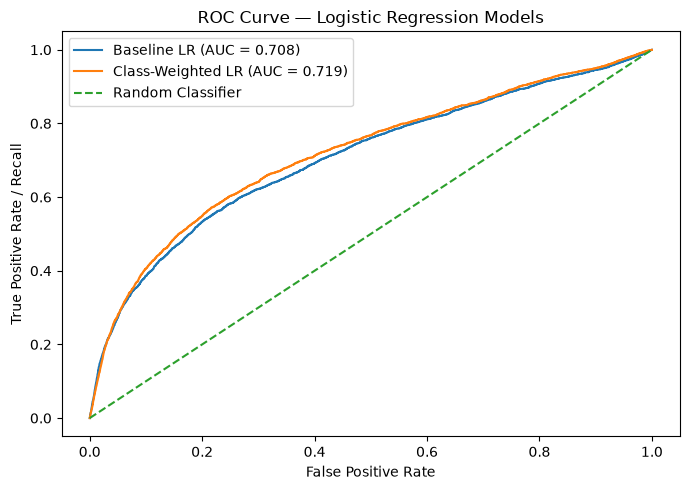

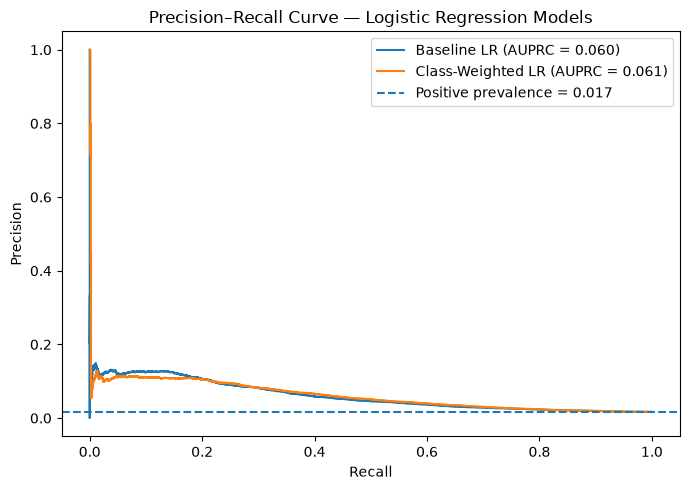

In [31]:
# CELL 30 — ROC and Precision-Recall curves

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

# ---------------------------------------------------
# ROC curves
# ---------------------------------------------------

fpr_base, tpr_base, _ = roc_curve(
    y_test,
    y_prob_baseline
)

fpr_bal, tpr_bal, _ = roc_curve(
    y_test,
    y_prob_balanced
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_base,
    tpr_base,
    label=f"Baseline LR (AUC = {roc_auc:.3f})"
)

plt.plot(
    fpr_bal,
    tpr_bal,
    label=f"Class-Weighted LR (AUC = {roc_auc_b:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve — Logistic Regression Models")
plt.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# Precision-Recall curves
# ---------------------------------------------------

precision_curve_base, recall_curve_base, _ = (
    precision_recall_curve(
        y_test,
        y_prob_baseline
    )
)

precision_curve_bal, recall_curve_bal, _ = (
    precision_recall_curve(
        y_test,
        y_prob_balanced
    )
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall_curve_base,
    precision_curve_base,
    label=f"Baseline LR (AUPRC = {auprc:.3f})"
)

plt.plot(
    recall_curve_bal,
    precision_curve_bal,
    label=f"Class-Weighted LR (AUPRC = {auprc_b:.3f})"
)

# Positive-class prevalence as reference baseline
positive_rate = y_test.mean()

plt.axhline(
    y=positive_rate,
    linestyle="--",
    label=f"Positive prevalence = {positive_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Logistic Regression Models")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
# CELL 31 — Final Review 1 summary

print("=" * 65)
print("ABHISHEK — REVIEW 1 FINAL SUMMARY")
print("=" * 65)

print("\n1. DATASET")
print(f"Total patients               : {combined_df['Patient_Key'].nunique():,}")
print(f"Total hourly observations    : {len(combined_df):,}")
print(f"Number of model features     : {len(model_features)}")

print("\n2. CLASS DISTRIBUTION")
print("Patient-level Sepsis         : 7.27%")
print("Patient-level Non-Sepsis     : 92.73%")
print("Hour-level SepsisLabel = 1   : 1.80%")
print("Hour-level SepsisLabel = 0   : 98.20%")

print("\n3. DATA PREPARATION")
print("Duplicate rows               : 0")
print("Duplicate patient-hours      : 0")
print("Infinite values              : 0")
print("Patient-level split          : 80% Train / 20% Test")
print("Train/Test patient overlap   : 0")
print("Forward-fill reduction       : ~46.8%")
print("Final missing X_train values : 0")
print("Final missing X_test values  : 0")
print("Continuous features scaled   : 37")
print("Binary features unchanged    : 3")

print("\n4. FINAL DATASETS")
print(f"X_train : {X_train_scaled.shape}")
print(f"X_test  : {X_test_scaled.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

print("\n5. LOGISTIC REGRESSION RESULTS")

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1-score",
        "ROC-AUC",
        "AUPRC"
    ],
    "Baseline LR": [
        accuracy,
        precision,
        recall,
        specificity,
        f1,
        roc_auc,
        auprc
    ],
    "Class-Weighted LR": [
        accuracy_b,
        precision_b,
        recall_b,
        specificity_b,
        f1_b,
        roc_auc_b,
        auprc_b
    ]
})

final_results[
    ["Baseline LR", "Class-Weighted LR"]
] = final_results[
    ["Baseline LR", "Class-Weighted LR"]
].round(4)

display(final_results)

print("\n6. KEY INTERPRETATION")
print(
    "Baseline LR achieved very high accuracy but detected almost "
    "none of the positive Sepsis-warning observations."
)

print(
    "Class weighting substantially improved sensitivity/recall, "
    "but increased false-positive warnings."
)

print(
    "Therefore, class imbalance strongly influences model behaviour "
    "and accuracy alone is unsuitable for this problem."
)

print("\n" + "=" * 65)
print("ABHISHEK REVIEW 1 — COMPLETE")
print("=" * 65)

ABHISHEK — REVIEW 1 FINAL SUMMARY

1. DATASET
Total patients               : 30,338
Total hourly observations    : 1,163,798
Number of model features     : 40

2. CLASS DISTRIBUTION
Patient-level Sepsis         : 7.27%
Patient-level Non-Sepsis     : 92.73%
Hour-level SepsisLabel = 1   : 1.80%
Hour-level SepsisLabel = 0   : 98.20%

3. DATA PREPARATION
Duplicate rows               : 0
Duplicate patient-hours      : 0
Infinite values              : 0
Patient-level split          : 80% Train / 20% Test
Train/Test patient overlap   : 0
Forward-fill reduction       : ~46.8%
Final missing X_train values : 0
Final missing X_test values  : 0
Continuous features scaled   : 37
Binary features unchanged    : 3

4. FINAL DATASETS
X_train : (931285, 40)
X_test  : (232513, 40)
y_train : (931285,)
y_test  : (232513,)

5. LOGISTIC REGRESSION RESULTS


,Metric,Baseline LR,Class-Weighted LR
0,Accuracy,0.9828,0.7500
1,Precision,0.1095,0.0398
2,Recall,0.0038,0.6010
3,Specificity,0.9995,0.7526
4,F1-score,0.0074,0.0747
5,ROC-AUC,0.7078,0.7194
6,AUPRC,0.0599,0.0606



6. KEY INTERPRETATION
Baseline LR achieved very high accuracy but detected almost none of the positive Sepsis-warning observations.
Class weighting substantially improved sensitivity/recall, but increased false-positive warnings.
Therefore, class imbalance strongly influences model behaviour and accuracy alone is unsuitable for this problem.

ABHISHEK REVIEW 1 — COMPLETE


In [33]:
# CELL 32 — Save Review 1 modelling data for Akilan

import joblib
from pathlib import Path

HANDOFF_DIR = PROCESSED_DIR   # keep handoff files inside the repo (data/processed)
HANDOFF_DIR.mkdir(parents=True, exist_ok=True)

# Save the common modelling dataset
model_data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,
    "model_features": model_features,
    "train_patient_keys": train_patient_keys,
    "test_patient_keys": test_patient_keys
}

joblib.dump(
    model_data,
    HANDOFF_DIR / "model_data.joblib",
    compress=3
)

# Save the scaler separately
joblib.dump(
    scaler,
    HANDOFF_DIR / "preprocessing_scaler.joblib",
    compress=3
)

print("Handoff files saved successfully to:")
print(HANDOFF_DIR)

Handoff files saved successfully to:
d:\SepsiChronos HDA\data\processed
